In [11]:
import os
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from skimage import measure
from skimage.morphology import remove_small_objects
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.summary import VoltageSummary
from vip_slap2_analysis.utils.utils import save_figure

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [12]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures"

In [4]:
# ---------------------------------------------------------------------
# Local repository / data paths
# ---------------------------------------------------------------------
# If running from inside the repo, this can usually stay as None.
# If imports fail, set REPO_ROOT to your local clone, e.g.
# REPO_ROOT = Path(r"C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis")
REPO_ROOT = None

if REPO_ROOT is not None:
    src_path = Path(REPO_ROOT) / "src"
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")

# Optional local copy of the summary table. The registry discovers sessions from BASE_PATH;
# this file is only useful for ad hoc inspection or manual cross-checks.
SUMMARY_XLSX = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\VIP_SD_summary.xlsx")

# ---------------------------------------------------------------------
# Session selection
# ---------------------------------------------------------------------
target_mice = [
    826031,
    826032,
]

EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]
PARADIGMS = ["change_detection_passive"]

In [5]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions for target mice: {target_mice}")
display(process_df.head())

Found 19 candidate sessions for target mice: [826031, 826032]


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


In [6]:
asset = assets[1]
vs = VoltageSummary(asset.modality_assets['voltage']['summary_mat'])
print(asset.session_id)

826031_2026-02-01_11-01-50


In [7]:
dmd1_ref = vs.get_ref_plane(dmd=1)
dmd2_ref = vs.get_ref_plane(dmd=2)

In [8]:
dmd1_masks = vs.get_roi_masks(dmd=1)
dmd2_masks = vs.get_roi_masks(dmd=2)

<IPython.core.display.Javascript object>


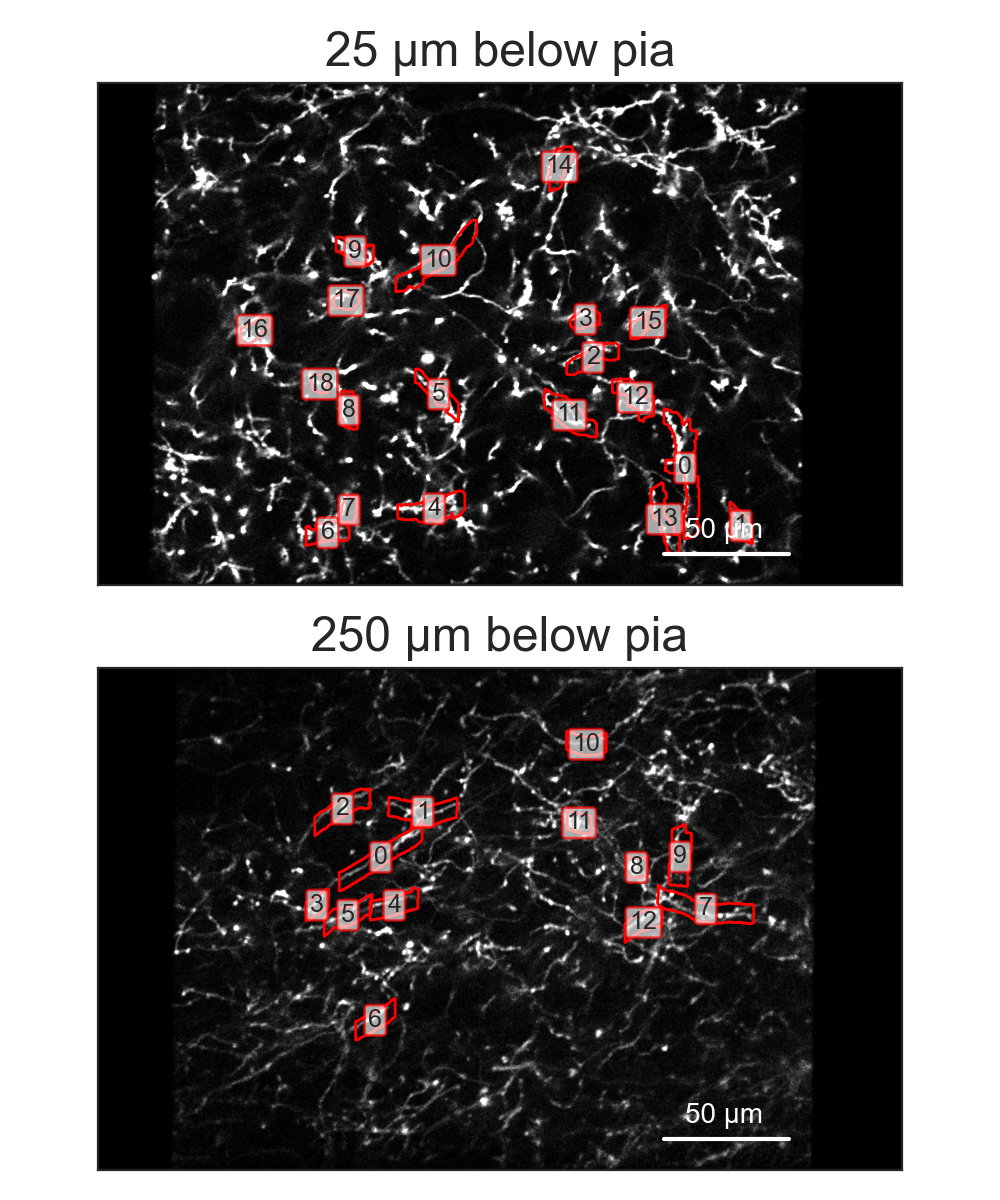

In [10]:
fig,ax=plt.subplots(2,figsize=(5,6),sharex=True)

scale = 0.25 #um/pxl
titles = ['25 \u03BCm below pia','250 \u03BCm below pia']
ref_ims = [dmd1_ref,dmd2_ref]
masks = [dmd1_masks,dmd2_masks]

for i,axis in enumerate(ax.flatten()):
    axis.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    axis.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

    axis.imshow(ref_ims[i],cmap='Greys_r',vmin=0,vmax=150)
    
    for ii,mask in enumerate(masks[i].transpose(2,0,1)):
        con = axis.contour(mask.astype(float), levels=[0.5], linewidths=1)
        con.set_color('red')
        con.set_facecolor('none')
        yy, xx = np.nonzero(mask)
        axis.text(float(np.mean(xx)), float(np.mean(yy)), f"{ii}",
                ha="center", va="center", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="red", alpha=0.65))

    # # Match image coordinates
    # ax.set_aspect('equal')
    # ax.invert_yaxis()
    # ax.axis('off')

    axis.set_xticks([])
    axis.set_yticks([])
    
    sb = 50
    pxl_strt = 900
    y = 750
    axis.plot([pxl_strt,pxl_strt+sb/scale],[y,y],color='w')
    axis.text(pxl_strt+sb/scale/6,y-25,'50 \u03BCm',color='w')
    
    axis.set_title(titles[i])

fig.tight_layout()
filen = 'Example_dmd_roi_overlay'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf','.png'],dpi=300)